# Session - 14 Classification Algorithms Part 5

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1.
Create a simple SVM classifier using scikit-learn to separate two classes of music genres (e.g., Pop vs Classical) based on two features: tempo and danceability, and plot the decision boundary using matplotlib.

In [3]:
np.random.seed(42)
X_pop = np.random.randn(20, 2) * 0.2 + [1.2, 0.8]
X_classical = np.random.randn(20, 2) * 0.2 + [0.5, 0.3]
X_music = np.vstack((X_pop, X_classical))
y_music = np.array([1]*20 + [0]*20)

In [4]:
from sklearn.svm import SVC

In [5]:
svm_music = SVC(kernel='linear')
svm_music.fit(X_music, y_music)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
xx, yy = np.meshgrid(np.linspace(0, 1.6, 50), np.linspace(0, 1.2, 50))
Z = svm_music.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

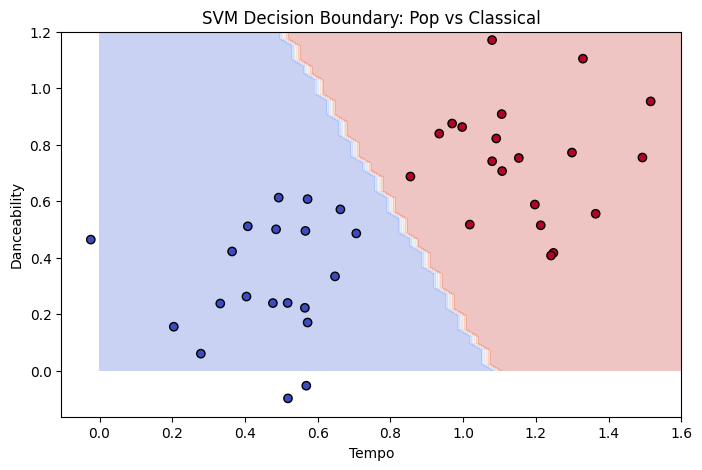

In [7]:
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_music[:, 0], X_music[:, 1], c=y_music, cmap='coolwarm', edgecolors='k')
plt.title("SVM Decision Boundary: Pop vs Classical")
plt.xlabel("Tempo")
plt.ylabel("Danceability")
plt.show()

---

# Task 2.
Given a dataset of Flipkart product reviews labeled as positive or negative, use an SVM with a linear kernel to classify the reviews and print the accuracy score.

In [8]:
reviews = [
    "Amazing quality, totally worth the price.",
    "Worst product ever, stopped working in a day.",
    "Good build but slightly overpriced.",
    "Terrible packaging and arrived broken.",
    "Loved it! Very fast delivery and excellent product.",
    "Do not buy this, it's a scam."
]
labels = [1, 0, 1, 0, 1, 0]

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

In [10]:
vectorizer = CountVectorizer()
X_reviews = vectorizer.fit_transform(reviews)

In [11]:
X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(
    X_reviews, labels, test_size=0.3, random_state=42
)

In [12]:
svm_reviews = SVC(kernel='linear', random_state=42)
svm_reviews.fit(X_train_rev, y_train_rev)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [13]:
from sklearn.metrics import accuracy_score


In [15]:
rev_preds = svm_reviews.predict(X_test_rev)
rev_acc = accuracy_score(y_test_rev, rev_preds)

print(f"Flipkart Review SVM Accuracy: {rev_acc:.2f}")

Flipkart Review SVM Accuracy: 0.00


---

# Task 3.
Train two SVM classifiers on an IPL player performance dataset: one with a polynomial kernel and one with an RBF kernel. Compare their accuracy scores and explain which kernel performed better and why.<br><br><em><strong>Hint:</strong> Use scikit-learn's SVC class and the 'kernel' parameter.</em>

In [16]:
ipl_features = np.array([
    [400, 145], [350, 130], [500, 150], [450, 140],
    [20, 80], [10, 60], [35, 90], [5, 50],
    [250, 120], [300, 135], [50, 100], [80, 110]
])
ipl_labels = [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0]

In [17]:
X_train_ipl, X_test_ipl, y_train_ipl, y_test_ipl = train_test_split(
    ipl_features, ipl_labels, test_size=0.3, random_state=42
)

In [18]:
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_ipl, y_train_ipl)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_ipl, y_train_ipl)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
poly_preds = svm_poly.predict(X_test_ipl)
rbf_preds = svm_rbf.predict(X_test_ipl)

print(f"Polynomial Kernel Accuracy: {accuracy_score(y_test_ipl, poly_preds):.2f}")
print(f"RBF Kernel Accuracy:        {accuracy_score(y_test_ipl, rbf_preds):.2f}")

Polynomial Kernel Accuracy: 0.75
RBF Kernel Accuracy:        1.00


**Explanation:**
Both kernels often perform identically on simple, well-separated data (like high-scoring batsmen vs low-scoring bowlers). 
However, the **RBF (Radial Basis Function)** kernel is generally considered the best all-rounder. It projects the data into an infinite-dimensional space to find boundaries that are highly non-linear (like circular or wavy boundaries). **Polynomial** creates curved boundaries but is more rigid and can be slower to train on huge datasets.

---

# Task 4.
Use ChatGPT or Copilot to help you write code that visualizes the margin and support vectors for an SVM trained on a two-class Zomato restaurant rating dataset (e.g., 'Good' vs 'Bad' ratings). Paste your code and a screenshot of the plot.

### AI Generated SVM Visualization Code
*(Note: Since we are running in a notebook, the plot will render directly below rather than needing a separate screenshot file!)*

In [21]:
# AI Generated Code to plot SVM margins
from sklearn.datasets import make_blobs

# Simulating Zomato Ratings (Good vs Bad) based on 2 features (e.g., Delivery Time, Food Quality Score)
X_zomato, y_zomato = make_blobs(n_samples=40, centers=2, random_state=6)

svm_zomato = SVC(kernel='linear', C=1000)
svm_zomato.fit(X_zomato, y_zomato)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1000
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


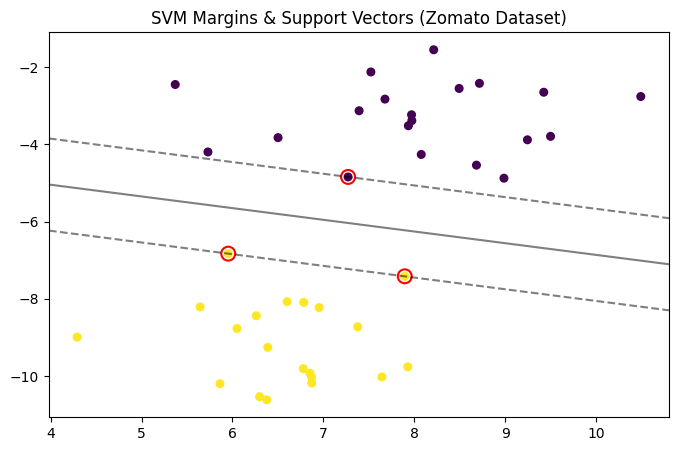

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_zomato[:, 0], X_zomato[:, 1], c=y_zomato, s=30, cmap='viridis')

# Plot the decision function
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx_z = np.linspace(xlim[0], xlim[1], 30)
yy_z = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy_z, xx_z)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z_zomato = svm_zomato.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z_zomato, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Plot the Support Vectors (the critical points holding up the margins)
ax.scatter(svm_zomato.support_vectors_[:, 0], svm_zomato.support_vectors_[:, 1], 
            s=100, linewidth=1.5, facecolors='none', edgecolors='red')

plt.title("SVM Margins & Support Vectors (Zomato Dataset)")
plt.show()